In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [82]:
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
'Central Air', 'Total Bsmt SF', 'SalePrice']

In [83]:
df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt',
            sep='\t',
            usecols=columns)

In [84]:
df['Central Air'] = df['Central Air'].map({'N': 0, 'Y': 1})

In [85]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [86]:
df = df.dropna(axis=0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

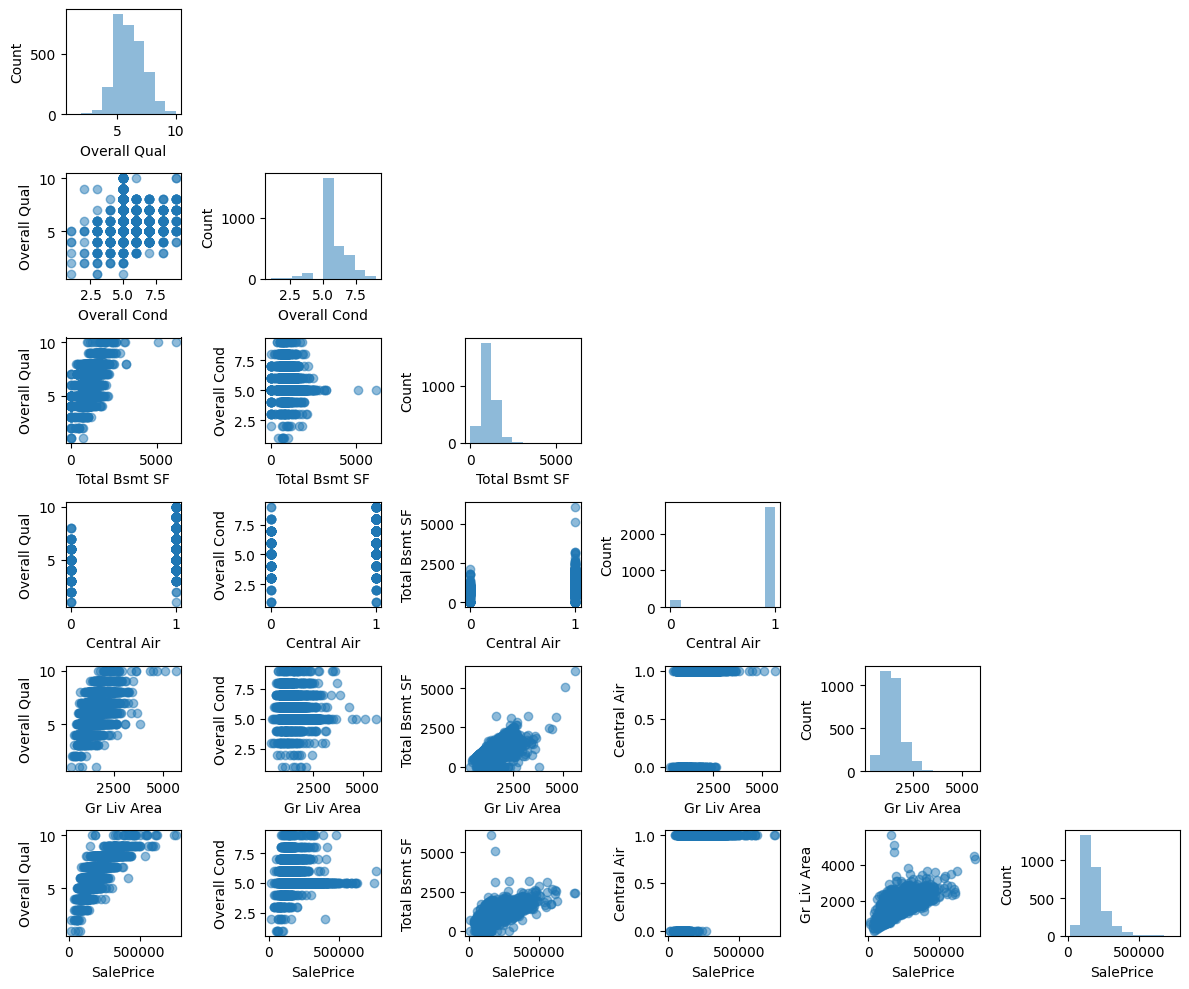

In [87]:
from mlxtend.plotting import scatterplotmatrix
scatterplotmatrix(df.values, figsize=(12, 10),
                  names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

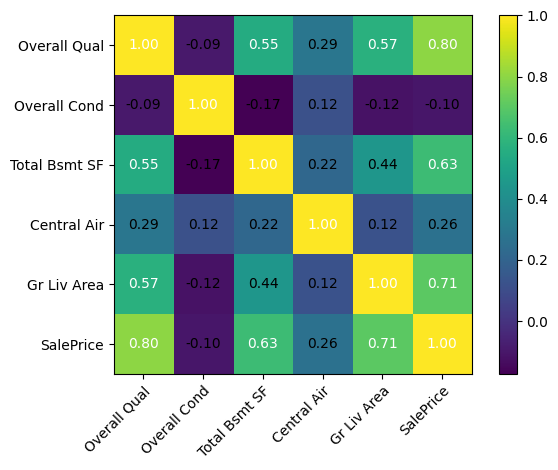

In [88]:
from mlxtend.plotting import heatmap
cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)
plt.tight_layout()
plt.show()

In [89]:
from linear_reg import LinearRegression
from sklearn.preprocessing import StandardScaler

In [90]:
X = df[['Gr Liv Area']].values 
y = df['SalePrice'].values

x_sc, y_sc = StandardScaler(), StandardScaler()

X_std = x_sc.fit_transform(X)
y_std = y_sc.fit_transform(y.reshape(-1, 1)).flatten()

In [91]:
y_std.shape

(2929,)

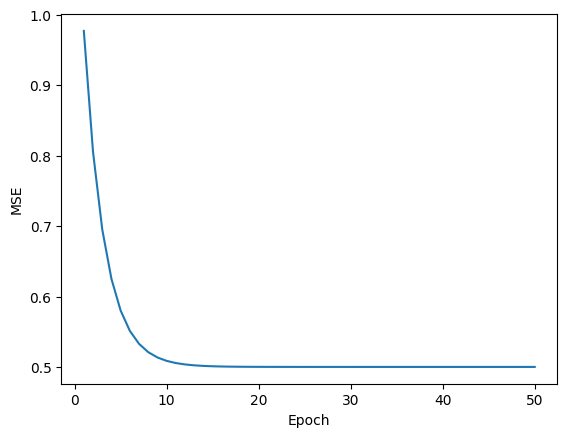

In [92]:
lr = LinearRegression(eta=0.1)
lr.fit(X_std, y_std)

plt.plot(range(1, lr.n_iter + 1), lr.losses_)
plt.ylabel("MSE")
plt.xlabel('Epoch')
plt.show()


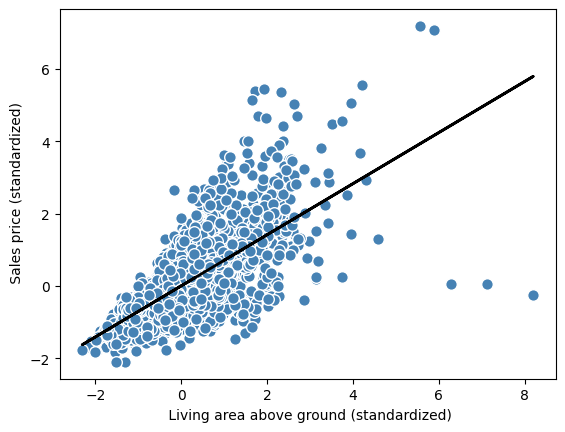

In [93]:
lr.lin_regplot(X_std, y_std)
plt.xlabel(' Living area above ground (standardized)')
plt.ylabel(' Sales price (standardized)')
plt.show()

In [94]:
feature_std = x_sc.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)

target_reversed = y_sc.inverse_transform(target_std.reshape(-1, 1))
print(f' Sales price ${target_reversed.flatten()[0]:.2f}')

 Sales price $292507.07


In [95]:
from sklearn.linear_model import LinearRegression

In [96]:
slr = LinearRegression()

In [97]:
slr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
y_pred = slr.predict(X)

In [99]:
print(f'Slope: {slr.coef_[0]:.3f}')

print(f'Intercept: {slr.intercept_:.3f}')

Slope: 111.666
Intercept: 13342.979


In [100]:
Xb = np.hstack((np.ones((X.shape[0], 1)), X))
w = np.zeros(X.shape[1])

z = np.linalg.inv(np.dot(Xb.T, Xb))
w = np.dot(z, np.dot(Xb.T, y))

print(f'Slope: {w[1]:.3f}')

print(f'Intercept: {w[0]:.3f}')

Slope: 111.666
Intercept: 13342.979


In [101]:
from sklearn.linear_model import RANSACRegressor
ransac = RANSACRegressor(
    LinearRegression(),
    max_trials=100,
    min_samples=0.95,
    residual_threshold=None,
    random_state=123
)

ransac.fit(X, y)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",0.95
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionadded:: 0.18"

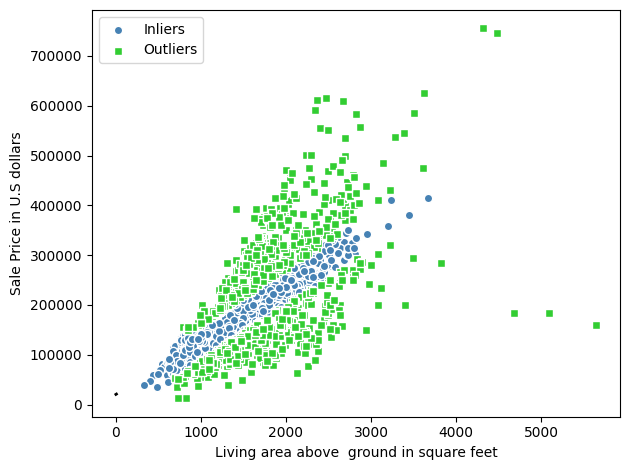

In [102]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)
line_X = np.arange(3, 10, 1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])

plt.scatter(X[inlier_mask], y[inlier_mask], c='steelblue',
            edgecolors='white', marker='o', label='Inliers')

plt.scatter(X[outlier_mask], y[outlier_mask], c='limegreen',
            edgecolors='white', marker='s', label='Outliers')
plt.plot(line_X, line_y_ransac, color='black', lw=2)
plt.xlabel('Living area above  ground in square feet')
plt.ylabel('Sale Price in U.S dollars')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

In [103]:
from sklearn.model_selection import train_test_split
target = 'SalePrice'
features = df.columns[df.columns != target]
X = df[features].values
y = df[target].values

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [105]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_test_pred), np.min(y_train_pred)])

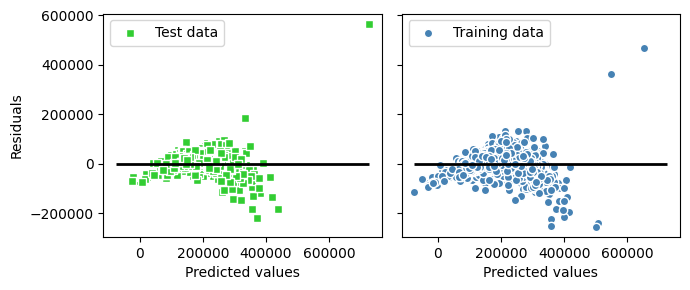

In [106]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
ax1.scatter(
    y_test_pred, y_test_pred - y_test, c='limegreen',
    marker='s', edgecolor='white', label='Test data'
)

ax2.scatter(
    y_train_pred, y_train_pred - y_train,
    c='steelblue', marker='o', edgecolor='white',
    label='Training data'
)

ax1.set_ylabel('Residuals')
for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100,
              color='black', lw=2)
plt.tight_layout()
plt.show()

In [107]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f'Training MSE: {mse_train:.2f}\nTest MSE: {mse_test:.2f}')

Training MSE: 1497216245.85
Test MSE: 1516565821.00


In [108]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'Training MAE: {mae_train:.2f}\nTest MAE: {mae_test:.2f}')

Training MAE: 25983.03
Test MAE: 24921.29


In [109]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'Train R^2: {train_r2:.2f}\nTest R^2: {test_r2:.2f}')

Train R^2: 0.77
Test R^2: 0.75


In [110]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pandas as pd



models = {

    'Ridge': Ridge(alpha=1.0),

    'Lasso': Lasso(alpha=1.0),

    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)

}



results = []



for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)

    y_test_pred = model.predict(X_test)



    results.append({

        'Model': model_name,

        'Train_MSE': mean_squared_error(y_train, y_train_pred),

        'Test_MSE': mean_squared_error(y_test, y_test_pred),

        'Train_MAE': mean_absolute_error(y_train, y_train_pred),

        'Test_MAE': mean_absolute_error(y_test, y_test_pred),

        'Train_R2Score': r2_score(y_train, y_train_pred),

        'Test_R2Score': r2_score(y_test, y_test_pred)

    })



results_df = pd.DataFrame(results)

results_df

,Model,Train_MSE,Test_MSE,Train_MAE,Test_MAE,Train_R2Score,Test_R2Score
0,Ridge,1.497217e+09,1.516670e+09,25982.436752,24921.207616,0.769495,0.751558
1,Lasso,1.497216e+09,1.516577e+09,25983.092032,24921.394737,0.769495,0.751573
2,ElasticNet,1.578091e+09,1.667097e+09,25994.084916,25274.256069,0.757044,0.726917


In [111]:
X = np.array([258.0, 270.0, 294.0, 320.0, 342.0, 368.0, 396.0, 446.0, 480.0, 586.0])[:, np.newaxis]
y = np.array([236.4, 234.4, 252.8, 298.6, 314.2,
              342.2, 360.8, 368.0, 391.2, 390.8])

In [112]:
from sklearn.preprocessing import PolynomialFeatures
lr = LinearRegression()
pr = LinearRegression()
quadratic = PolynomialFeatures(degree=2) 

X_quad = quadratic.fit_transform(X)

In [113]:
lr.fit(X, y)

X_fit = np.arange(250, 600, 10)[:, np.newaxis]

y_lin_fit = lr.predict(X_fit)

In [114]:
pr.fit(X_quad, y)
y_quad_fit = pr.predict(quadratic.fit_transform(X_fit))


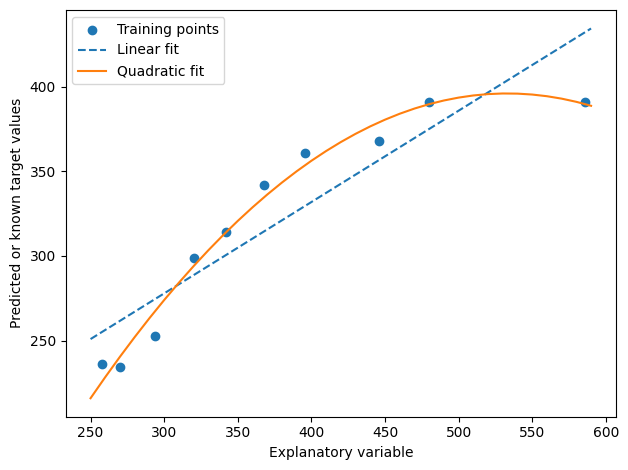

In [115]:
plt.scatter(X, y, label='Training points')
plt.plot(X_fit, y_lin_fit, label='Linear fit', linestyle='--')
plt.plot(X_fit, y_quad_fit, label='Quadratic fit')
plt.xlabel('Explanatory variable')
plt.ylabel('Predicted or known target values')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [116]:
y_lin_pred = lr.predict(X)
y_quad_pred = pr.predict(X_quad)
mse_lin = mean_squared_error(y, y_lin_pred)
mse_quad = mean_squared_error(y, y_quad_pred)

print(f'Training MSE linear : {mse_lin:.3f} '
      f'Quadtic: {mse_quad:.3f}'
      
       )

Training MSE linear : 569.780 Quadtic: 61.330


In [117]:
rs_lin = r2_score(y, y_lin_pred)
r2_quad = r2_score(y, y_quad_pred)

print(f'Training R^2 linear: {rs_lin:.3f} '
      f'Quadrati: {r2_quad:.3f}')

Training R^2 linear: 0.832 Quadrati: 0.982


In [118]:
# X = df[['Gr Liv Area']].values
# y = df['SalePrice'].values
# X = X[(df['Gr Liv Area'] < 4000)]
# y = y[(df['Gr Liv Area'] < 4000)]

X = df[['Overall Qual']].values
y = df['SalePrice'].values

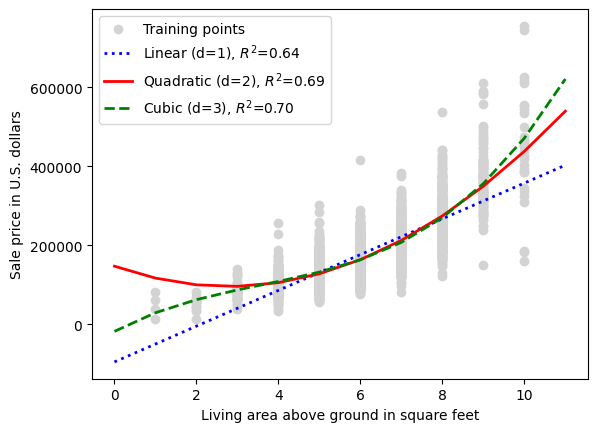

In [119]:
regr = LinearRegression()
# create quadratic and cubic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)
# fit to features
X_fit = np.arange(X.min()-1, X.max()+2, 1)[:, np.newaxis]
regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))
regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))
regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))
# plot results
plt.scatter(X, y, label='Training points', color='lightgray')
plt.plot(X_fit, y_lin_fit,
         label=f'Linear (d=1), $R^2$={linear_r2:.2f}',
         color='blue',
         lw=2,
         linestyle=':')
plt.plot(X_fit, y_quad_fit,
         label=f'Quadratic (d=2), $R^2$={quadratic_r2:.2f}',
         color='red',
         lw=2,
         linestyle='-')
plt.plot(X_fit, y_cubic_fit,
         label=f'Cubic (d=3), $R^2$={cubic_r2:.2f}',
         color='green',
         lw=2,
         linestyle='--')
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')
plt.show()

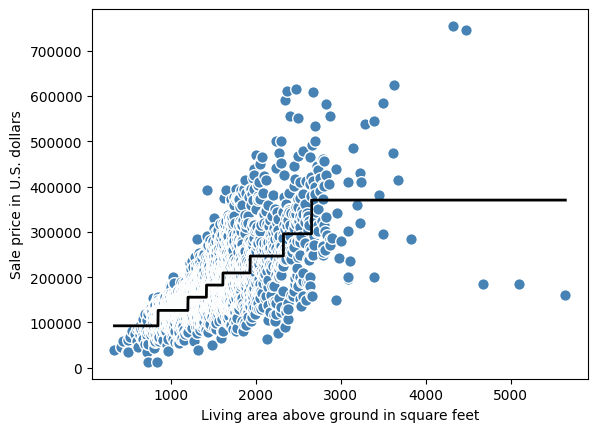

In [120]:
from sklearn.tree import DecisionTreeRegressor
from linear_reg import lin_regplot
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)
sort_idx = X.flatten().argsort()
lin_regplot(X[sort_idx], y[sort_idx], tree)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.show()